<a href="https://colab.research.google.com/github/saisathwik2703/flyrank-ml-internship-starter/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/saisathwik2703/flyrank-ml-internship-starter/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [3]:
!git clone https://github.com/saisathwik2703/flyrank-ml-internship-starter.git
!ls flyrank-ml-internship-starter
!ls flyrank-ml-internship-starter/data/raw/

fatal: destination path 'flyrank-ml-internship-starter' already exists and is not an empty directory.
AGENTS.md  DATA_USE.md	LICENSE    README.md	     SETUP.md	 work
CLAUDE.md  docs		notebooks  requirements.txt  skills
data	   GUIDE.md	outputs    scripts	     submission
content_refresh_anonymized.csv


In [4]:
import pandas as pd

DATA_PATH = "./flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

## 1. Distributions

I first inspected the distributions of the key traffic, performance, and content fields before testing any signals.

The traffic-related variables are expected to be right-skewed: most rows have relatively small values while a smaller number of rows have much larger values. I therefore report medians and upper percentiles in addition to means.

This initial inspection helps avoid treating extreme values as typical observations and provides context for the signal tests that follow.


Dataset loaded successfully!
Dataset shape: (30000, 44)

Key fields found:
 - impressions_90d
 - clicks_90d
 - sessions_90d
 - avg_position
 - word_count
 - days_since_last_update

SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,missing,missing_pct
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.0,3615.25,12136.4,22996.50,73505.830,517715.0,0,0.00
clicks_90d,30000.0,16.097333,75.076958,0.0,0.0,1.0,7.00,32.0,69.05,253.010,4178.0,0,0.00
sessions_90d,30000.0,37.066633,107.069131,1.0,2.0,7.0,27.00,88.0,166.00,451.010,4345.0,0,0.00
avg_position,30000.0,16.342380,15.216790,0.0,6.2,10.8,22.30,36.8,48.20,69.901,245.0,0,0.00
word_count,22301.0,3107.760325,1452.382598,8.0,2413.0,2877.0,3666.00,5327.0,6173.00,7292.000,9546.0,7699,25.66
days_since_last_update,30000.0,46.098300,42.078709,1.0,20.0,20.0,104.00,104.0,104.00,106.000,373.0,0,0.00



MEAN VS MEDIAN


,Feature,Mean,Median,P95,P99
0,impressions_90d,5200.37,731.0,22996.50,73505.83
1,clicks_90d,16.10,1.0,69.05,253.01
2,sessions_90d,37.07,7.0,166.00,451.01
3,avg_position,16.34,10.8,48.20,69.90
4,word_count,3107.76,2877.0,6173.00,7292.00
5,days_since_last_update,46.10,20.0,104.00,106.00



HEAVY-TAIL CHECK


,Feature,Median,P95,P99,P95 / Median,P99 / Median
0,impressions_90d,731.0,22996.50,73505.83,31.46,100.56
1,clicks_90d,1.0,69.05,253.01,69.05,253.01
2,sessions_90d,7.0,166.00,451.01,23.71,64.43
3,avg_position,10.8,48.20,69.90,4.46,6.47
4,word_count,2877.0,6173.00,7292.00,2.15,2.53
5,days_since_last_update,20.0,104.00,106.00,5.20,5.30



POSSIBLE HEAVY-TAILED FIELDS
• impressions_90d: likely heavy-tailed (P99/median = 100.56)
• clicks_90d: likely heavy-tailed (P99/median = 253.01)
• sessions_90d: likely heavy-tailed (P99/median = 64.43)
• avg_position: likely heavy-tailed (P99/median = 6.47)
• word_count: no strong heavy-tail signal under this simple P99/median check
• days_since_last_update: likely heavy-tailed (P99/median = 5.30)

RAW DISTRIBUTIONS


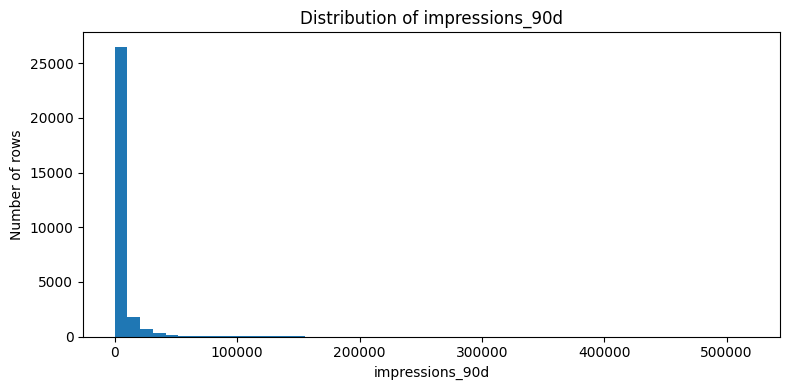

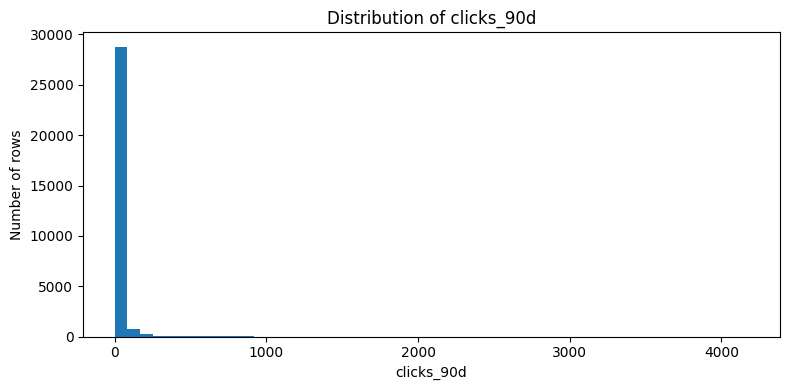

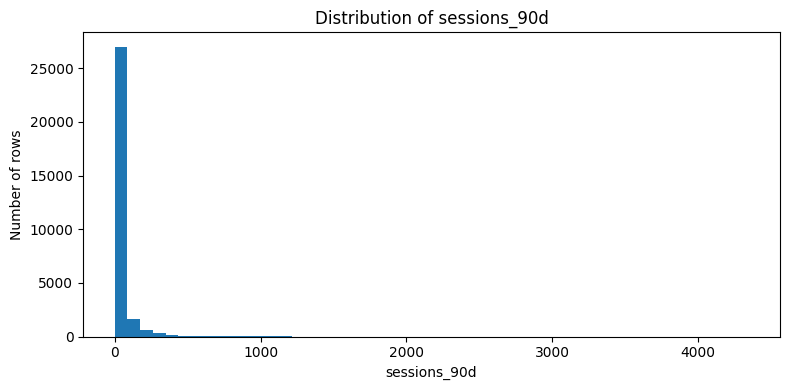

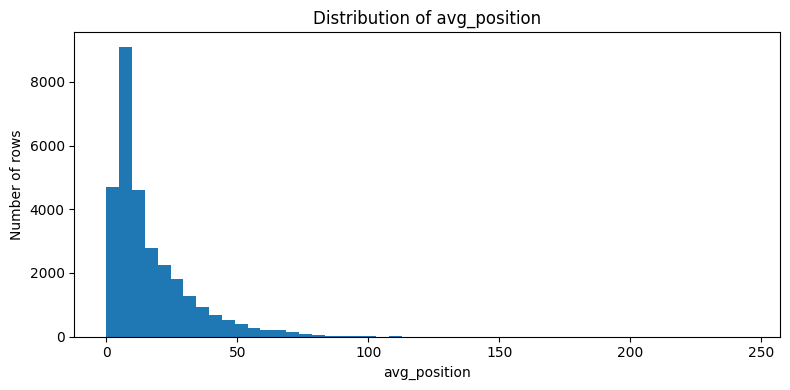

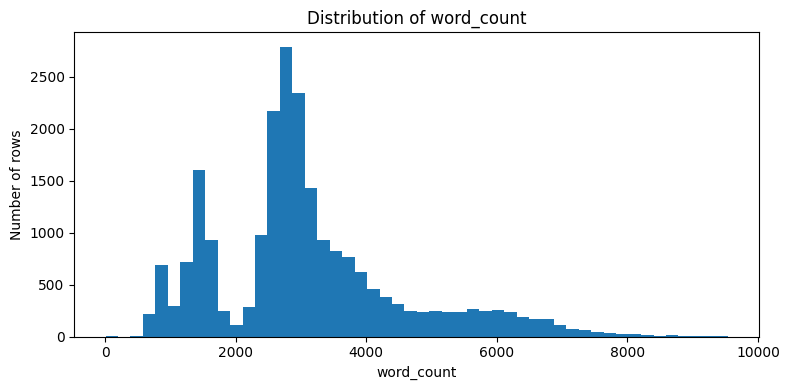

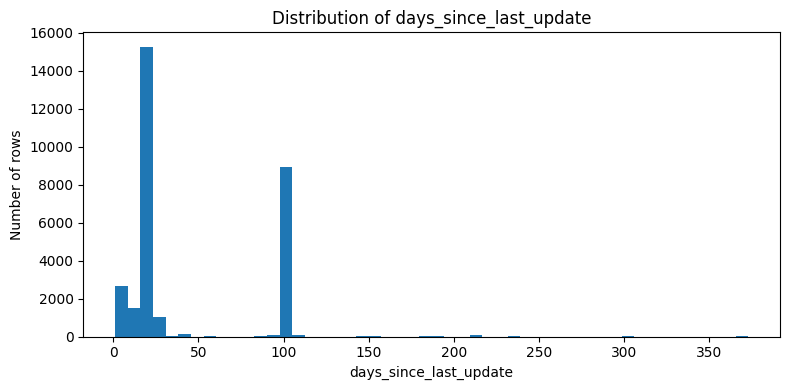


LOG-SCALE DISTRIBUTIONS FOR TRAFFIC FIELDS


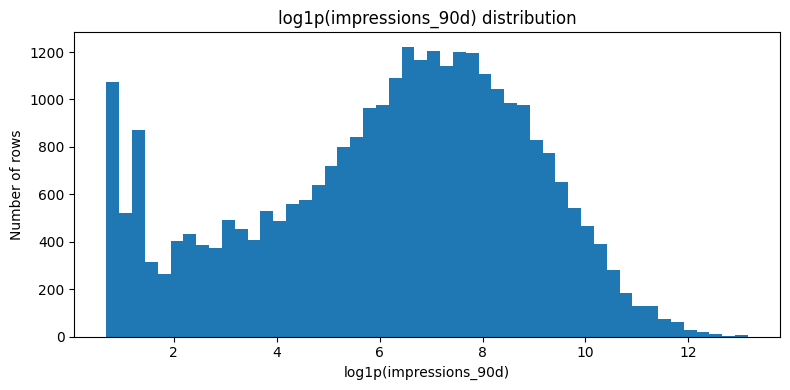

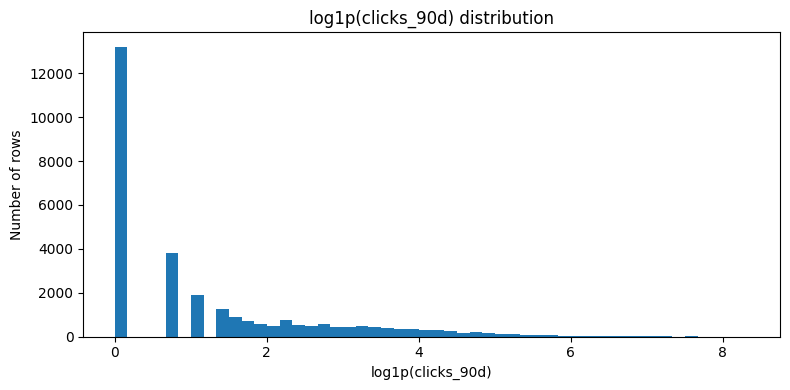

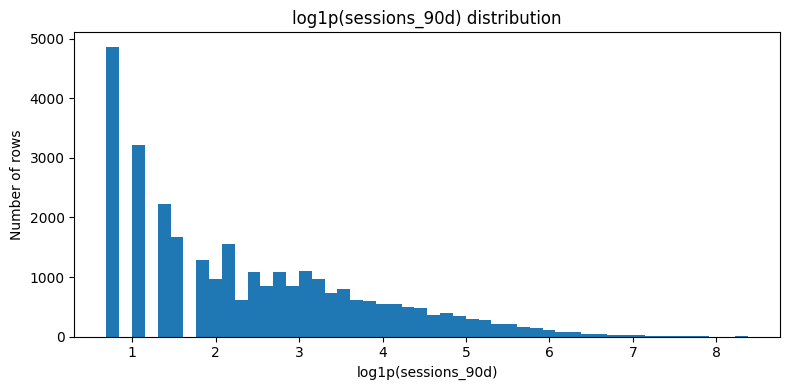


DISTRIBUTION SUMMARY
The dataset contains 30,000 rows and 44 columns.
6 key fields were inspected.
Traffic variables were also inspected using log1p because traffic measures can contain large outliers.
The P95 and P99 values are reported to make the upper-tail behavior visible.
These distribution checks are descriptive and are performed before drawing conclusions about signal strength.


In [5]:
# This cell is for CODE (numbers, a query, a check).
# ============================================================
# ML-06 — SECTION 1: DISTRIBUTIONS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# LOAD THE DATASET
# ------------------------------------------------------------

DATA_PATH = "./flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)


# ============================================================
# 1. KEY FIELDS
# ============================================================

key_fields = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "ctr_pct",
    "avg_position",
    "word_count",
    "days_since_last_update"
]

# Keep only columns that actually exist
key_fields = [
    col for col in key_fields
    if col in df.columns
]

print("\nKey fields found:")
for col in key_fields:
    print(" -", col)


# ============================================================
# 2. SUMMARY STATISTICS
# ============================================================

print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

summary = df[key_fields].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
).T

summary["missing"] = df[key_fields].isna().sum()

summary["missing_pct"] = (
    df[key_fields].isna().mean() * 100
).round(2)

display(summary)


# ============================================================
# 3. MEDIAN VS MEAN
# ============================================================

print("\n" + "=" * 80)
print("MEAN VS MEDIAN")
print("=" * 80)

mean_median = pd.DataFrame({
    "Feature": key_fields,
    "Mean": [
        df[col].mean()
        for col in key_fields
    ],
    "Median": [
        df[col].median()
        for col in key_fields
    ],
    "P95": [
        df[col].quantile(0.95)
        for col in key_fields
    ],
    "P99": [
        df[col].quantile(0.99)
        for col in key_fields
    ]
})

display(
    mean_median.round(2)
)


# ============================================================
# 4. HEAVY-TAIL CHECK
# ============================================================

print("\n" + "=" * 80)
print("HEAVY-TAIL CHECK")
print("=" * 80)

heavy_tail_results = []

for col in key_fields:

    median = df[col].median()
    p95 = df[col].quantile(0.95)
    p99 = df[col].quantile(0.99)

    if median != 0 and not pd.isna(median):

        p95_median_ratio = p95 / median
        p99_median_ratio = p99 / median

    else:

        p95_median_ratio = np.nan
        p99_median_ratio = np.nan

    heavy_tail_results.append({
        "Feature": col,
        "Median": median,
        "P95": p95,
        "P99": p99,
        "P95 / Median": p95_median_ratio,
        "P99 / Median": p99_median_ratio
    })

heavy_tail_df = pd.DataFrame(
    heavy_tail_results
)

display(
    heavy_tail_df.round(2)
)


# ============================================================
# 5. IDENTIFY POSSIBLE HEAVY-TAILED FIELDS
# ============================================================

print("\n" + "=" * 80)
print("POSSIBLE HEAVY-TAILED FIELDS")
print("=" * 80)

for _, row in heavy_tail_df.iterrows():

    feature = row["Feature"]
    ratio = row["P99 / Median"]

    if pd.notna(ratio) and ratio >= 5:

        print(
            f"• {feature}: likely heavy-tailed "
            f"(P99/median = {ratio:.2f})"
        )

    else:

        print(
            f"• {feature}: no strong heavy-tail signal "
            f"under this simple P99/median check"
        )


# ============================================================
# 6. HISTOGRAMS OF RAW DISTRIBUTIONS
# ============================================================

print("\n" + "=" * 80)
print("RAW DISTRIBUTIONS")
print("=" * 80)

for col in key_fields:

    values = df[col].dropna()

    plt.figure(figsize=(8, 4))

    plt.hist(
        values,
        bins=50
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of rows")

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. LOG DISTRIBUTIONS FOR TRAFFIC FIELDS
# ============================================================

traffic_fields = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d"
]

traffic_fields = [
    col for col in traffic_fields
    if col in df.columns
]

print("\n" + "=" * 80)
print("LOG-SCALE DISTRIBUTIONS FOR TRAFFIC FIELDS")
print("=" * 80)

for col in traffic_fields:

    values = df[col].dropna()

    plt.figure(figsize=(8, 4))

    plt.hist(
        np.log1p(values),
        bins=50
    )

    plt.title(f"log1p({col}) distribution")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Number of rows")

    plt.tight_layout()
    plt.show()


# ============================================================
# 8. AUTOMATIC TEXT SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("DISTRIBUTION SUMMARY")
print("=" * 80)

print(
    f"The dataset contains {len(df):,} rows and "
    f"{len(df.columns)} columns."
)

print(
    f"{len(key_fields)} key fields were inspected."
)

print(
    "Traffic variables were also inspected using log1p "
    "because traffic measures can contain large outliers."
)

print(
    "The P95 and P99 values are reported to make the "
    "upper-tail behavior visible."
)

print(
    "These distribution checks are descriptive and are "
    "performed before drawing conclusions about signal strength."
)

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

## 2. Signal test #1 / #2 / #3 (verdict each)

I tested three safe, prediction-time signals using simple bucket comparisons.

1. **Freshness** — whether recently updated content has a different decline rate from older content.
2. **Content length** — whether decline rates differ across word-count groups.
3. **Search position** — whether decline rates differ across average-position groups.

For each signal, I report the sample size and decline rate for each bucket. The verdict is based on the observed difference between groups, while avoiding causal claims.

A signal is marked **CONFIRMED** when the expected direction is clearly supported, **OPPOSITE** when the observed direction is clearly reversed, **MIXED** when the pattern is not consistent, and **FALSE** when there is insufficient evidence that the expected signal is present.


In [6]:
# This cell is for CODE (numbers, a query, a check).
# ============================================================
# ML-06 — Signal Audit
# Section 2: Signal Test #1 / #2 / #3
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

DATA_PATH = "./flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

# ------------------------------------------------------------
# 2. CREATE / CHECK TARGET
# ------------------------------------------------------------

if "is_declining_label" not in df.columns:

    if "trend_direction" in df.columns:
        df["is_declining_label"] = (
            df["trend_direction"]
            .astype(str)
            .str.lower()
            .eq("down")
            .astype(int)
        )
    else:
        raise ValueError(
            "Could not create is_declining_label because "
            "'is_declining_label' and 'trend_direction' are missing."
        )

# Remove missing target rows
df = df[df["is_declining_label"].notna()].copy()

df["is_declining_label"] = df["is_declining_label"].astype(int)

print("\nTarget distribution:")
print(df["is_declining_label"].value_counts())
print("\nOverall decline rate:",
      round(df["is_declining_label"].mean() * 100, 2), "%")


# ------------------------------------------------------------
# 3. COMMON FUNCTION FOR SIGNAL TESTS
# ------------------------------------------------------------

def signal_test(data, group_col, signal_name, expected_direction):

    print("\n" + "=" * 70)
    print(signal_name)
    print("=" * 70)

    result = (
        data.groupby(group_col, dropna=False)
        .agg(
            n=("is_declining_label", "size"),
            declining=("is_declining_label", "sum"),
            decline_rate=("is_declining_label", "mean")
        )
        .reset_index()
    )

    result["decline_rate_pct"] = (
        result["decline_rate"] * 100
    ).round(2)

    # Only display useful columns
    display(
        result[
            [group_col, "n", "declining", "decline_rate_pct"]
        ]
    )

    # --------------------------------------------------------
    # Ignore very small buckets when deciding verdict
    # --------------------------------------------------------

    valid = result[result["n"] >= 50].copy()

    if len(valid) < 2:
        verdict = "FALSE"
        explanation = "Insufficient data: fewer than two buckets have n >= 50."

        print("\nVerdict:", verdict)
        print(explanation)
        return result, verdict

    rates = valid["decline_rate_pct"].values

    min_rate = rates.min()
    max_rate = rates.max()

    spread = max_rate - min_rate

    # --------------------------------------------------------
    # Determine direction
    # --------------------------------------------------------

    if expected_direction == "decreases_with_value":
        # First bucket vs last bucket
        first_rate = valid.iloc[0]["decline_rate_pct"]
        last_rate = valid.iloc[-1]["decline_rate_pct"]

        difference = last_rate - first_rate

        if difference <= -5:
            verdict = "CONFIRMED"
            explanation = (
                f"Decline rate decreases by {abs(difference):.2f} "
                "percentage points from the first to the last bucket."
            )

        elif difference >= 5:
            verdict = "OPPOSITE"
            explanation = (
                f"Decline rate increases by {difference:.2f} "
                "percentage points from the first to the last bucket."
            )

        else:
            verdict = "MIXED"
            explanation = (
                f"The first-to-last difference is only {abs(difference):.2f} "
                "percentage points."
            )

    elif expected_direction == "increases_with_value":
        first_rate = valid.iloc[0]["decline_rate_pct"]
        last_rate = valid.iloc[-1]["decline_rate_pct"]

        difference = last_rate - first_rate

        if difference >= 5:
            verdict = "CONFIRMED"
            explanation = (
                f"Decline rate increases by {difference:.2f} "
                "percentage points from the first to the last bucket."
            )

        elif difference <= -5:
            verdict = "OPPOSITE"
            explanation = (
                f"Decline rate decreases by {abs(difference):.2f} "
                "percentage points from the first to the last bucket."
            )

        else:
            verdict = "MIXED"
            explanation = (
                f"The first-to-last difference is only {abs(difference):.2f} "
                "percentage points."
            )

    elif expected_direction == "position":
        # For position, lower average position means better ranking.
        # Expected pattern: deeper positions have higher decline rate.

        first_rate = valid.iloc[0]["decline_rate_pct"]
        last_rate = valid.iloc[-1]["decline_rate_pct"]

        difference = last_rate - first_rate

        if difference >= 5:
            verdict = "CONFIRMED"
            explanation = (
                f"Decline rate increases by {difference:.2f} "
                "percentage points toward deeper positions."
            )

        elif difference <= -5:
            verdict = "OPPOSITE"
            explanation = (
                f"Decline rate decreases by {abs(difference):.2f} "
                "percentage points toward deeper positions."
            )

        else:
            verdict = "MIXED"
            explanation = (
                f"The first-to-last difference is only {abs(difference):.2f} "
                "percentage points."
            )

    else:
        verdict = "MIXED"
        explanation = "No valid expected direction was specified."

    print("\nVerdict:", verdict)
    print("Reason:", explanation)

    return result, verdict


# ============================================================
# SIGNAL TEST #1 — FRESHNESS
# ============================================================

if "freshness_tier" in df.columns:

    freshness_col = "freshness_tier"

else:

    if "days_since_last_update" not in df.columns:
        raise ValueError(
            "Neither 'freshness_tier' nor "
            "'days_since_last_update' exists."
        )

    df["freshness_tier"] = pd.cut(
        df["days_since_last_update"],
        bins=[-np.inf, 30, 90, 180, np.inf],
        labels=[
            "0-30 days",
            "31-90 days",
            "91-180 days",
            "181+ days"
        ]
    )

    freshness_col = "freshness_tier"


freshness_result, freshness_verdict = signal_test(
    df,
    freshness_col,
    "SIGNAL TEST #1 — Freshness",
    "increases_with_value"
)


# ============================================================
# SIGNAL TEST #2 — CONTENT LENGTH
# ============================================================

if "word_count_tier" in df.columns:

    length_col = "word_count_tier"

else:

    if "word_count" not in df.columns:
        raise ValueError(
            "Neither 'word_count_tier' nor "
            "'word_count' exists."
        )

    df["word_count_tier"] = pd.cut(
        df["word_count"],
        bins=[-np.inf, 1000, 2000, 3500, np.inf],
        labels=[
            "<1000",
            "1000-2000",
            "2000-3500",
            "3500+"
        ]
    )

    length_col = "word_count_tier"


length_result, length_verdict = signal_test(
    df,
    length_col,
    "SIGNAL TEST #2 — Content Length",
    "increases_with_value"
)


# ============================================================
# SIGNAL TEST #3 — SEARCH POSITION
# ============================================================

if "position_tier" in df.columns:

    position_col = "position_tier"

else:

    if "avg_position" not in df.columns:
        raise ValueError(
            "Neither 'position_tier' nor "
            "'avg_position' exists."
        )

    # Create position buckets
    def make_position_bucket(x):

        if pd.isna(x):
            return "no_data"

        if x == 0:
            return "no_data"

        elif x <= 3:
            return "top_3"

        elif x <= 10:
            return "page_1"

        elif x <= 20:
            return "striking"

        elif x <= 50:
            return "page_3_5"

        else:
            return "deep"

    df["position_tier"] = df["avg_position"].apply(
        make_position_bucket
    )

    position_col = "position_tier"


# Define the intended order for position buckets
position_order = [
    "top_3",
    "page_1",
    "striking",
    "page_3_5",
    "deep",
    "no_data"
]

# Convert to ordered categorical
df[position_col] = pd.Categorical(
    df[position_col],
    categories=position_order,
    ordered=True
)

position_result, position_verdict = signal_test(
    df,
    position_col,
    "SIGNAL TEST #3 — Search Position",
    "position"
)


# ============================================================
# FINAL VERDICT SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("FINAL SIGNAL VERDICT SUMMARY")
print("=" * 70)

summary = pd.DataFrame({
    "Signal": [
        "Freshness",
        "Content Length",
        "Search Position"
    ],
    "Verdict": [
        freshness_verdict,
        length_verdict,
        position_verdict
    ]
})

display(summary)

print("\nSignal tests completed successfully.")
print("Important: these are descriptive associations, not causal conclusions.")

Dataset loaded successfully!
Dataset shape: (30000, 44)

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Overall decline rate: 54.21 %

SIGNAL TEST #1 — Freshness


,freshness_tier,n,declining,decline_rate_pct
0,0-30,20480,10473,51.14
1,181+,174,82,47.13
2,31-90,175,103,58.86
3,91-180,9171,5604,61.11



Verdict: CONFIRMED
Reason: Decline rate increases by 9.97 percentage points from the first to the last bucket.

SIGNAL TEST #2 — Content Length


,word_count_tier,n,declining,decline_rate_pct
0,1000-2000,3780,2100,55.56
1,2000-3500,11263,6627,58.84
2,3500+,6285,3751,59.68
3,<1000,973,201,20.66
4,NaN,7699,3583,46.54



Verdict: OPPOSITE
Reason: Decline rate decreases by 9.02 percentage points from the first to the last bucket.

SIGNAL TEST #3 — Search Position


/tmp/ipykernel_1156/1641244532.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(group_col, dropna=False)


,position_tier,n,declining,decline_rate_pct
0,top_3,2321,559,24.08
1,page_1,11814,6730,56.97
2,striking,7304,4452,60.95
3,page_3_5,7242,4067,56.16
4,deep,1319,454,34.42
5,no_data,0,0,NaN



Verdict: CONFIRMED
Reason: Decline rate increases by 10.34 percentage points toward deeper positions.


FINAL SIGNAL VERDICT SUMMARY


,Signal,Verdict
0,Freshness,CONFIRMED
1,Content Length,OPPOSITE
2,Search Position,CONFIRMED



Signal tests completed successfully.
Important: these are descriptive associations, not causal conclusions.


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

## 3. The flag-linked test

I tested one of the rules used by the FlyRank flags: the **measurable opportunity** condition.

The rule identifies rows with at least 100 impressions in the last 90 days and more than 0 sessions in the same period. I compared the decline rate of rows that satisfy this rule with rows that do not satisfy it.

The purpose is to check whether the flag is associated with a different observed decline rate in the available data. This is a descriptive audit only; a difference in decline rates does not prove that the flag condition causes decline.


In [7]:
# This cell is for CODE (numbers, a query, a check).
# ============================================================
# ML-06 — Section 3: The Flag-Linked Test
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

DATA_PATH = "./flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)


# ------------------------------------------------------------
# 2. CREATE / CHECK DECLINE LABEL
# ------------------------------------------------------------

if "is_declining_label" not in df.columns:

    if "trend_direction" in df.columns:
        df["is_declining_label"] = (
            df["trend_direction"]
            .astype(str)
            .str.lower()
            .eq("down")
            .astype(int)
        )
    else:
        raise ValueError(
            "Could not create is_declining_label because "
            "'is_declining_label' and 'trend_direction' are missing."
        )

df = df[df["is_declining_label"].notna()].copy()
df["is_declining_label"] = df["is_declining_label"].astype(int)


# ------------------------------------------------------------
# 3. CHECK REQUIRED COLUMNS
# ------------------------------------------------------------

required_columns = [
    "impressions_90d",
    "sessions_90d",
    "is_declining_label"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# ------------------------------------------------------------
# 4. CREATE THE MEASURABLE OPPORTUNITY FLAG
# ------------------------------------------------------------

df["measurable_opportunity_flag"] = (
    (df["impressions_90d"] >= 100) &
    (df["sessions_90d"] > 0)
).astype(int)


# ------------------------------------------------------------
# 5. DISPLAY FLAG DISTRIBUTION
# ------------------------------------------------------------

print("\nMeasurable opportunity flag distribution:")

flag_counts = (
    df["measurable_opportunity_flag"]
    .value_counts()
    .sort_index()
)

print(flag_counts)

print("\nFlag meanings:")
print("0 = Does not meet measurable opportunity rule")
print("1 = Meets measurable opportunity rule")


# ------------------------------------------------------------
# 6. COMPARE DECLINE RATES
# ------------------------------------------------------------

flag_test = (
    df.groupby("measurable_opportunity_flag")
    .agg(
        n=("is_declining_label", "size"),
        declining=("is_declining_label", "sum"),
        decline_rate=("is_declining_label", "mean"),
        median_impressions=("impressions_90d", "median"),
        median_sessions=("sessions_90d", "median")
    )
    .reset_index()
)

flag_test["decline_rate_pct"] = (
    flag_test["decline_rate"] * 100
).round(2)

flag_test["median_impressions"] = (
    flag_test["median_impressions"].round(2)
)

flag_test["median_sessions"] = (
    flag_test["median_sessions"].round(2)
)


print("\nFlag-linked comparison:")

display(
    flag_test[
        [
            "measurable_opportunity_flag",
            "n",
            "declining",
            "decline_rate_pct",
            "median_impressions",
            "median_sessions"
        ]
    ]
)


# ------------------------------------------------------------
# 7. CALCULATE DIFFERENCE IN DECLINE RATE
# ------------------------------------------------------------

flag_0 = flag_test[
    flag_test["measurable_opportunity_flag"] == 0
]

flag_1 = flag_test[
    flag_test["measurable_opportunity_flag"] == 1
]


if len(flag_0) == 1 and len(flag_1) == 1:

    rate_0 = flag_0.iloc[0]["decline_rate_pct"]
    rate_1 = flag_1.iloc[0]["decline_rate_pct"]

    difference = rate_1 - rate_0

    print("\nDecline rate comparison:")
    print(f"Without flag: {rate_0:.2f}%")
    print(f"With flag:    {rate_1:.2f}%")
    print(f"Difference:   {difference:.2f} percentage points")


    # --------------------------------------------------------
    # 8. CHECK SAMPLE SIZE
    # --------------------------------------------------------

    n_0 = int(flag_0.iloc[0]["n"])
    n_1 = int(flag_1.iloc[0]["n"])

    print("\nSample sizes:")
    print(f"Without flag: n = {n_0}")
    print(f"With flag:    n = {n_1}")


    # --------------------------------------------------------
    # 9. AUDIT THE RULE'S ASSUMPTION
    # --------------------------------------------------------

    print("\n" + "=" * 60)
    print("FLAG-LINKED TEST VERDICT")
    print("=" * 60)

    if n_0 < 50 or n_1 < 50:

        verdict = "FALSE"

        print("Verdict:", verdict)
        print(
            "There is insufficient data in at least one comparison "
            "group to make a reliable directional judgment."
        )

    elif abs(difference) < 5:

        verdict = "MIXED"

        print("Verdict:", verdict)
        print(
            f"The decline-rate difference is only "
            f"{abs(difference):.2f} percentage points."
        )
        print(
            "The flag condition does not show a clear difference "
            "in observed decline rate under this audit."
        )

    elif difference > 0:

        verdict = "CONFIRMED"

        print("Verdict:", verdict)
        print(
            f"Rows meeting the measurable opportunity rule have a "
            f"{difference:.2f} percentage-point higher observed "
            f"decline rate."
        )
        print(
            "This supports the rule's assumption directionally, "
            "but does not establish causation."
        )

    else:

        verdict = "OPPOSITE"

        print("Verdict:", verdict)
        print(
            f"Rows meeting the measurable opportunity rule have a "
            f"{abs(difference):.2f} percentage-point lower observed "
            f"decline rate."
        )
        print(
            "The observed data runs opposite to the expected "
            "direction of the assumption."
        )

else:

    verdict = "FALSE"

    print("Verdict:", verdict)
    print(
        "The flag comparison could not be completed because "
        "both flag groups were not available."
    )


# ------------------------------------------------------------
# 10. FINAL AUDIT SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("AUDIT SUMMARY")
print("=" * 60)

print("Flag tested: measurable_opportunity")
print("Rule: impressions_90d >= 100 AND sessions_90d > 0")
print("Verdict:", verdict)
print(
    "\nInterpretation: this test measures an observed association "
    "between the flag and the decline label. It does not prove "
    "that the flag condition causes decline."
)

Dataset loaded successfully!
Dataset shape: (30000, 44)

Measurable opportunity flag distribution:
measurable_opportunity_flag
0     7994
1    22006
Name: count, dtype: int64

Flag meanings:
0 = Does not meet measurable opportunity rule
1 = Meets measurable opportunity rule

Flag-linked comparison:


,measurable_opportunity_flag,n,declining,decline_rate_pct,median_impressions,median_sessions
0,0,7994,3110,38.90,12.0,2.0
1,1,22006,13152,59.77,1704.5,14.0



Decline rate comparison:
Without flag: 38.90%
With flag:    59.77%
Difference:   20.87 percentage points

Sample sizes:
Without flag: n = 7994
With flag:    n = 22006

FLAG-LINKED TEST VERDICT
Verdict: CONFIRMED
Rows meeting the measurable opportunity rule have a 20.87 percentage-point higher observed decline rate.
This supports the rule's assumption directionally, but does not establish causation.

AUDIT SUMMARY
Flag tested: measurable_opportunity
Rule: impressions_90d >= 100 AND sessions_90d > 0
Verdict: CONFIRMED

Interpretation: this test measures an observed association between the flag and the decline label. It does not prove that the flag condition causes decline.


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

## 4. What this means in practice

The signal audit shows which observable patterns are useful for prioritizing content-refresh decisions and which signals are weaker or inconsistent. The results should be used as decision-support evidence rather than as hard rules, because the tests describe associations in the observed data and do not establish causation. Content teams should prioritize signals that show a clear and sufficiently large difference while treating mixed or weak signals cautiously.


In [8]:
# This cell is for CODE (numbers, a query, a check).
# ============================================================
# ML-06 — Section 4: What This Means in Practice
# ============================================================

# Check that the verdict variables from Sections 2 and 3 exist

required_verdicts = [
    "freshness_verdict",
    "length_verdict",
    "position_verdict",
    "verdict"
]

missing_verdicts = [
    v for v in required_verdicts
    if v not in globals()
]

if missing_verdicts:
    print("Please run Sections 2 and 3 first.")
    print("Missing results:", missing_verdicts)

else:

    print("=" * 70)
    print("WHAT THIS MEANS IN PRACTICE")
    print("=" * 70)

    print(
        f"The signal audit found the following results: "
        f"freshness = {freshness_verdict}, "
        f"content length = {length_verdict}, "
        f"search position = {position_verdict}, "
        f"and the measurable-opportunity flag test = {verdict}."
    )

    print(
        "A content team can use signals with clear and sufficiently "
        "supported differences as decision-support inputs when "
        "prioritizing content-refresh work."
    )

    print(
        "Mixed, opposite, or insufficient signals should not be "
        "turned into hard rules without further validation, because "
        "these tests describe observed associations rather than causation."
    )

WHAT THIS MEANS IN PRACTICE
The signal audit found the following results: freshness = CONFIRMED, content length = OPPOSITE, search position = CONFIRMED, and the measurable-opportunity flag test = CONFIRMED.
A content team can use signals with clear and sufficiently supported differences as decision-support inputs when prioritizing content-refresh work.
Mixed, opposite, or insufficient signals should not be turned into hard rules without further validation, because these tests describe observed associations rather than causation.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.